# Thermal Hotspot vs Tree Canopy Overlay

**Authored by:** Thien Khang Nguyen

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite Skills:** Python, Data Cleaning, Data Visualisation, Geospatial Analysis, Raster and Vector Data Handling, Spatial Overlay

Scenario

{As a student living in Melbourne, Khang has noticed that some parts of the city feel much hotter than others, especially during warm and dry days. When walking through different streets and open public spaces, he observed that areas with fewer trees often feel more exposed to heat, while areas with greater tree canopy tend to feel cooler and more comfortable. This made him interested in understanding whether these differences could be identified more clearly using spatial data.

Khang wants to have access to a system that can highlight Melbourne regions with high surface temperature and low tree canopy cover. By combining thermal imagery with tree canopy data, he hopes to identify urban areas that may be more vulnerable to heat and less protected by vegetation. This kind of analysis could help support discussions about urban heat resilience, canopy improvement, and greening priorities in future planning and environmental decision-making.}

{Introduction}

{Urban heat is a growing concern in cities, especially in areas with dense built surfaces, limited shade, and low vegetation cover. Surfaces such as roads, pavements, and rooftops can absorb and retain heat, causing some urban regions to become significantly warmer than others. Tree canopy plays an important role in reducing this effect by providing shade and contributing to urban cooling. Because of this, areas with high surface temperature and low canopy cover may be more vulnerable during hot weather conditions.

This use case focuses on identifying Melbourne regions where these two conditions may overlap. Instead of predicting future values over time, the project uses spatial analysis to compare a thermal image dataset with a tree canopy dataset. The thermal layer represents patterns of surface temperature, while the canopy layer represents the extent of urban tree cover. By analysing both datasets together, the project aims to highlight locations that may require greater attention in urban greening and heat resilience planning.

The datasets used in this project are the "Thermal Image 2012" dataset and the "Tree Canopies 2021 (Urban Forest)" dataset from the City of Melbourne website. Since the two datasets come from different years, the results should be interpreted as an exploratory spatial analysis rather than a same-time causal comparison. However, the project can still provide useful insight into broad spatial patterns of heat exposure and canopy distribution across Melbourne.}

# 1. Importing The Libraries

In [2]:
# Libraries for this project.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio

from rasterio.plot import show
from rasterio.mask import mask
from shapely.geometry import box

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Loading the Tree Canopy Dataset

In [3]:
# Load the tree canopy dataset.
canopy_gdf = gpd.read_file("tree-canopies-2021-urban-forest.geojson")

print("Tree canopy dataset loaded successfully.")

Tree canopy dataset loaded successfully.


In [4]:
# Display the first 5 rows.
canopy_gdf.head()

,geo_point_2d,geometry
0,"{'lon': 144.93898465421296, 'lat': -37.7750630...","MULTIPOLYGON (((144.93896 -37.77503, 144.93898..."
1,"{'lon': 144.93979253397976, 'lat': -37.7751329...","MULTIPOLYGON (((144.93979 -37.77512, 144.93979..."
2,"{'lon': 144.94145114868167, 'lat': -37.7753604...","MULTIPOLYGON (((144.94145 -37.77532, 144.94146..."
3,"{'lon': 144.9397185484928, 'lat': -37.77547666...","MULTIPOLYGON (((144.93972 -37.77547, 144.93972..."
4,"{'lon': 144.9389680913816, 'lat': -37.77536268...","MULTIPOLYGON (((144.93899 -37.77524, 144.939 -..."


In [5]:
# Check the shape of the dataset.
print("Dataset shape:", canopy_gdf.shape)

Dataset shape: (57980, 2)


In [6]:
# Display the column names.
print("Columns:")
print(canopy_gdf.columns)

Columns:
Index(['geo_point_2d', 'geometry'], dtype='str')


In [7]:
# Check the coordinate reference system.
print("CRS:", canopy_gdf.crs)

CRS: EPSG:4326


# 3. Inspecting the Geometry

In [8]:
# Check the geometry types.
print(canopy_gdf.geometry.geom_type.value_counts())

MultiPolygon    56979
Polygon          1001
Name: count, dtype: int64


# 4. Visualising the Tree Canopy Dataset

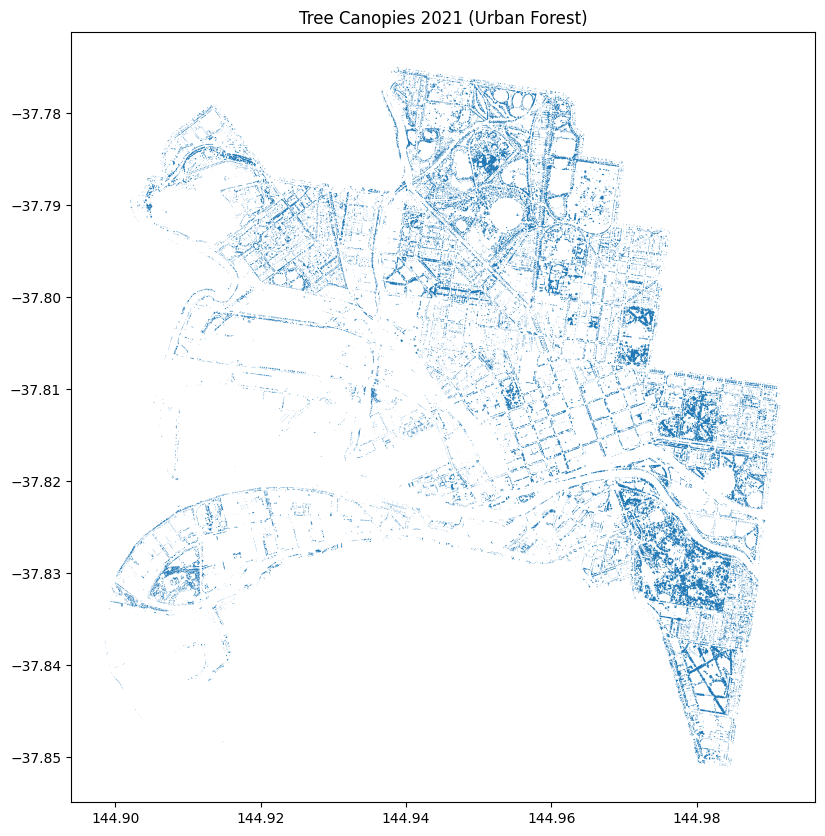

In [9]:
# Plot the tree canopy dataset.
fig, ax = plt.subplots(figsize=(10, 10))
canopy_gdf.plot(ax=ax)
ax.set_title("Tree Canopies 2021 (Urban Forest)")
plt.show()

# 5. Checking Data Quality

In [10]:
# Check missing values.
print(canopy_gdf.isnull().sum())

geo_point_2d    0
geometry        0
dtype: int64


# 6. Checking the Spatial Extent

In [11]:
# Check the total bounds of the dataset.
print("Total bounds:", canopy_gdf.total_bounds)

Total bounds: [144.89855037 -37.85111574 144.99167222 -37.77500116]


# 7. Creating a Cleaner Visualisation

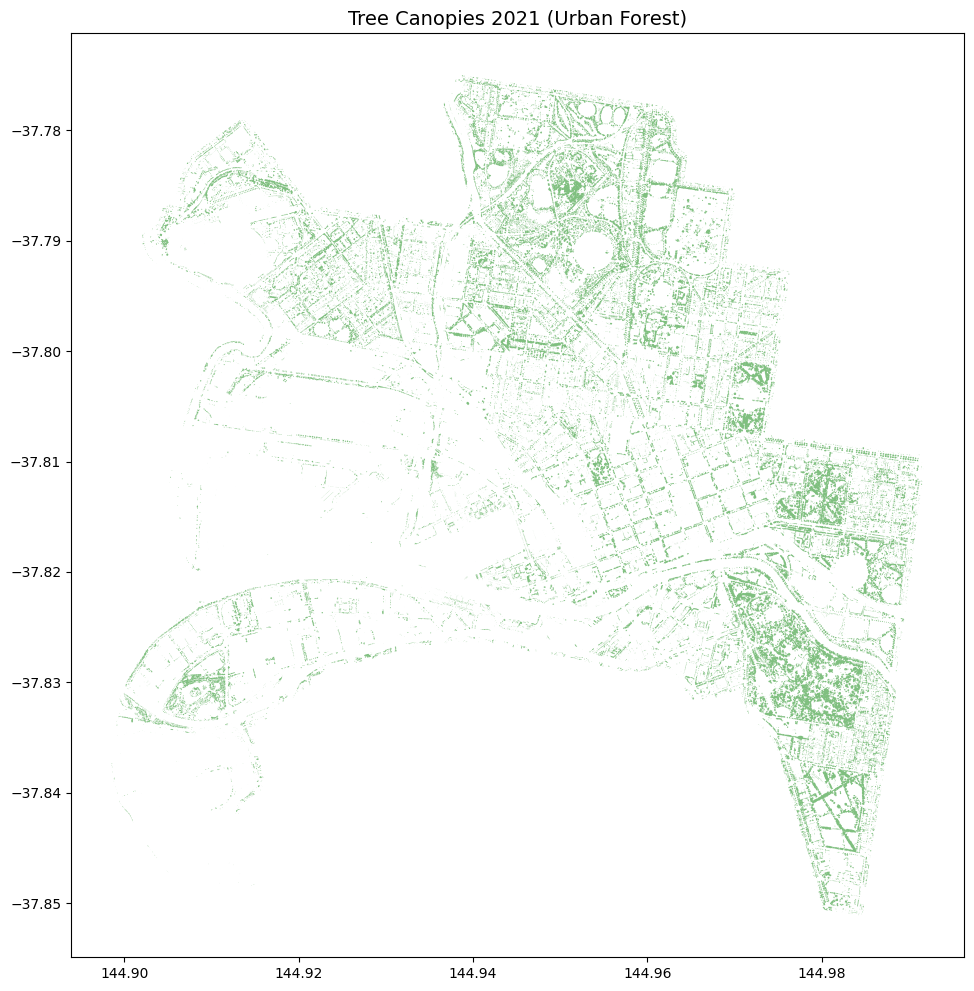

In [12]:
# Plot the tree canopy dataset with improved styling.
fig, ax = plt.subplots(figsize=(12, 12))
canopy_gdf.plot(ax=ax, color="green", edgecolor="none", alpha=0.5)
ax.set_title("Tree Canopies 2021 (Urban Forest)", fontsize=14)
plt.show()

# 8. Loading the Thermal Image Dataset

In [13]:
# Load the thermal image dataset.
thermal_src = rasterio.open("GeoTiff_1/Thermal.tif")

print("Thermal image dataset loaded successfully.")

Thermal image dataset loaded successfully.


In [14]:
# Display basic raster information.
print("CRS:", thermal_src.crs)
print("Bounds:", thermal_src.bounds)
print("Width:", thermal_src.width)
print("Height:", thermal_src.height)
print("Band count:", thermal_src.count)
print("Resolution:", thermal_src.res)

CRS: EPSG:28355
Bounds: BoundingBox(left=313125.50287426636, bottom=5808810.7843015315, right=326397.0294173194, top=5817743.135499577)
Width: 3919
Height: 2638
Band count: 3
Resolution: (3.3864573980742643, 3.386031538303843)


# 9. Inspecting the Thermal Image Bands

In [15]:
# Check the number of bands.
print("Band count:", thermal_src.count)

# Check dataset metadata.
print(thermal_src.meta)

Band count: 3
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 3919, 'height': 2638, 'count': 3, 'crs': CRS.from_wkt('PROJCS["GDA94 / MGA zone 55",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",147],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28355"]]'), 'transform': Affine(3.3864573980742643, 0.0, 313125.50287426636,
       0.0, -3.386031538303843, 5817743.135499577)}


In [16]:
# Read the first band.
thermal_band1 = thermal_src.read(1)

print("Band 1 shape:", thermal_band1.shape)
print("Band 1 minimum value:", thermal_band1.min())
print("Band 1 maximum value:", thermal_band1.max())

Band 1 shape: (2638, 3919)
Band 1 minimum value: 0
Band 1 maximum value: 255


# 10. Visualising the Thermal Image

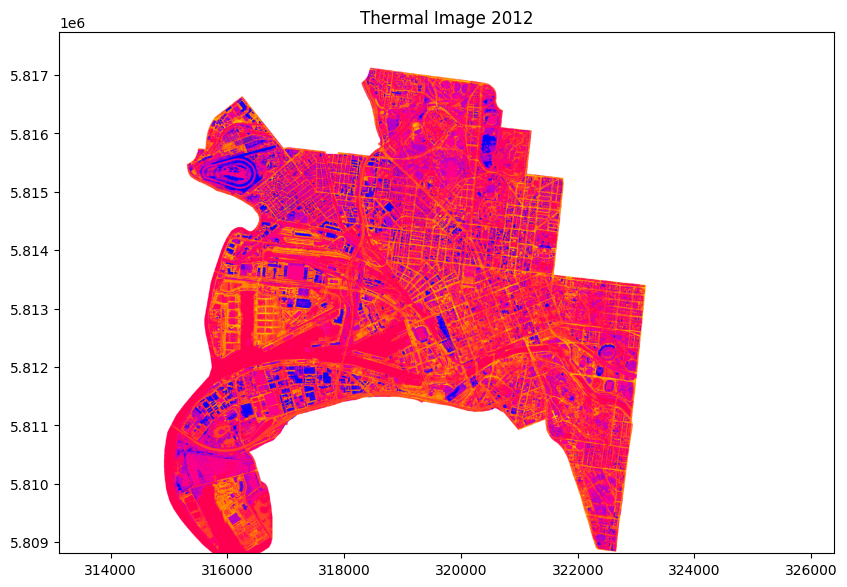

In [17]:
# Plot the thermal image.
fig, ax = plt.subplots(figsize=(10, 8))
show(thermal_src, ax=ax)
ax.set_title("Thermal Image 2012")
plt.show()

# 11. Reprojecting the Tree Canopy Dataset

In [18]:
# Reproject the canopy dataset to match the thermal image CRS.
canopy_projected = canopy_gdf.to_crs(thermal_src.crs)

print("Original canopy CRS:", canopy_gdf.crs)
print("Projected canopy CRS:", canopy_projected.crs)

Original canopy CRS: EPSG:4326
Projected canopy CRS: PROJCS["GDA94 / MGA zone 55",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",147],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28355"]]


In [19]:
# Check the projected canopy bounds.
print("Projected canopy bounds:", canopy_projected.total_bounds)
print("Thermal bounds:", thermal_src.bounds)

Projected canopy bounds: [ 315081.687  5808789.095   323212.6733 5817147.842 ]
Thermal bounds: BoundingBox(left=313125.50287426636, bottom=5808810.7843015315, right=326397.0294173194, top=5817743.135499577)


# 12. Visualising the Reprojected Tree Canopy Dataset

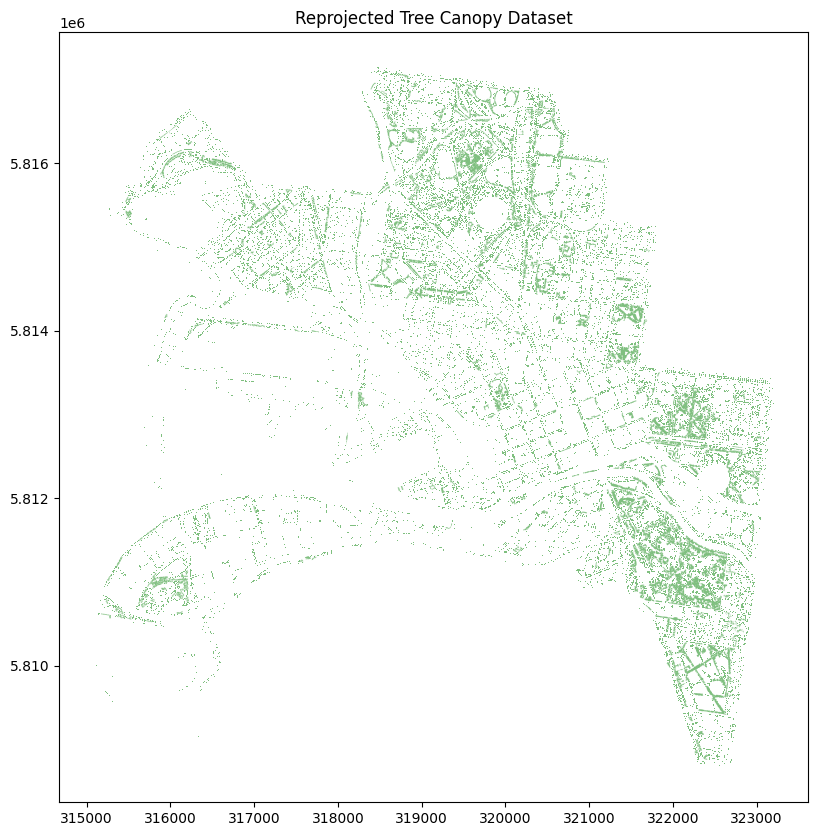

In [20]:
# Plot the reprojected canopy dataset.
fig, ax = plt.subplots(figsize=(10, 10))
canopy_projected.plot(ax=ax, color="green", edgecolor="none", alpha=0.5)
ax.set_title("Reprojected Tree Canopy Dataset")
plt.show()

# 13. Creating a Visual Overlay

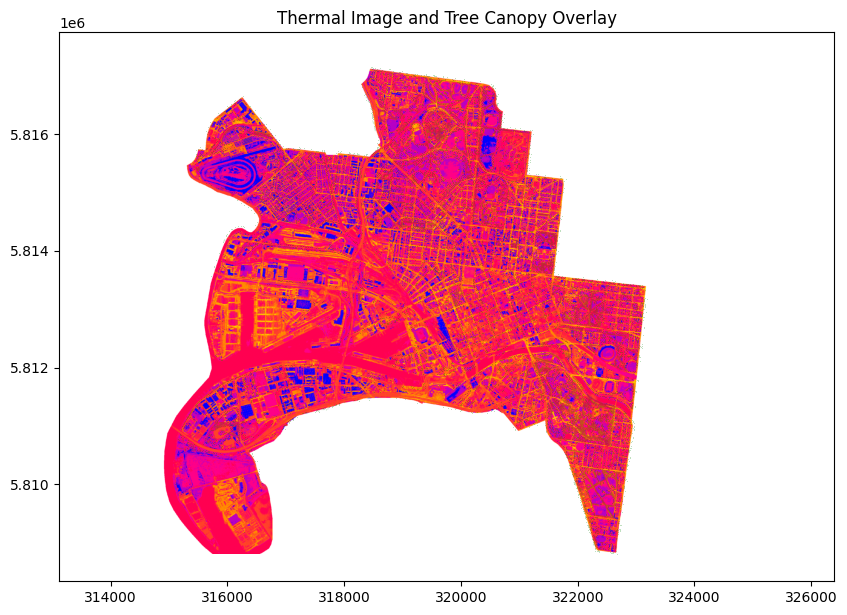

In [21]:
# Overlay the reprojected canopy dataset on top of the thermal image.
fig, ax = plt.subplots(figsize=(10, 10))

show(thermal_src, ax=ax)
canopy_projected.plot(ax=ax, color="green", edgecolor="none", alpha=0.25)

ax.set_title("Thermal Image and Tree Canopy Overlay")
plt.show()

# 14. Comparing the Spatial Extent

In [22]:
# Compare the bounds of the reprojected canopy dataset and the thermal image.
print("Reprojected canopy bounds:", canopy_projected.total_bounds)
print("Thermal bounds:", thermal_src.bounds)

Reprojected canopy bounds: [ 315081.687  5808789.095   323212.6733 5817147.842 ]
Thermal bounds: BoundingBox(left=313125.50287426636, bottom=5808810.7843015315, right=326397.0294173194, top=5817743.135499577)


# 15. Calculating Tree Canopy Area

In [23]:
# Calculate the area of each canopy geometry.
canopy_projected["canopy_area_m2"] = canopy_projected.geometry.area

print(canopy_projected["canopy_area_m2"].head())

0     43.315200
1      4.435200
2     55.987200
3      0.691200
4    248.141256
Name: canopy_area_m2, dtype: float64


In [24]:
# Display summary statistics for canopy area.
print(canopy_projected["canopy_area_m2"].describe())

count    57980.000000
mean        76.295950
std        676.024400
min          0.057600
25%          2.073600
50%         11.577600
75%         47.174400
max      90337.933129
Name: canopy_area_m2, dtype: float64


# 16. Exploring Tree Canopy Area Distribution

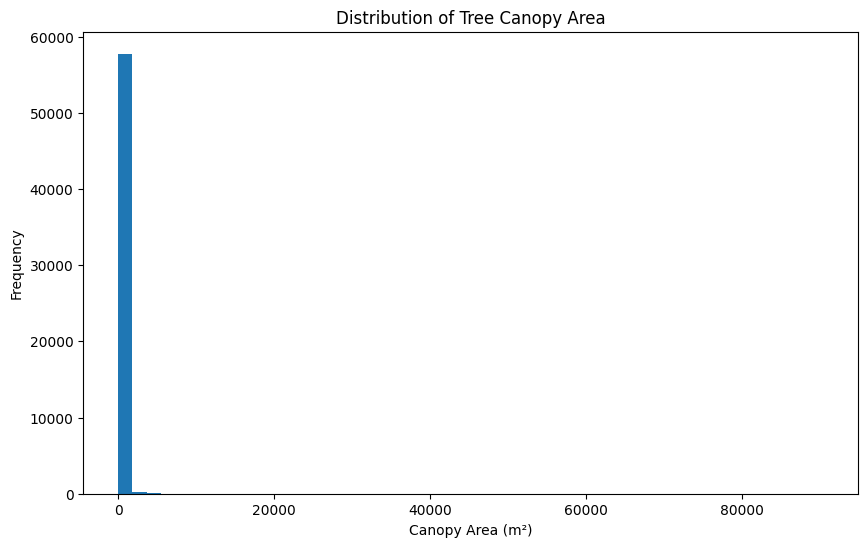

In [25]:
# Plot a histogram of canopy area.
plt.figure(figsize=(10, 6))
plt.hist(canopy_projected["canopy_area_m2"], bins=50)
plt.title("Distribution of Tree Canopy Area")
plt.xlabel("Canopy Area (m²)")
plt.ylabel("Frequency")
plt.show()

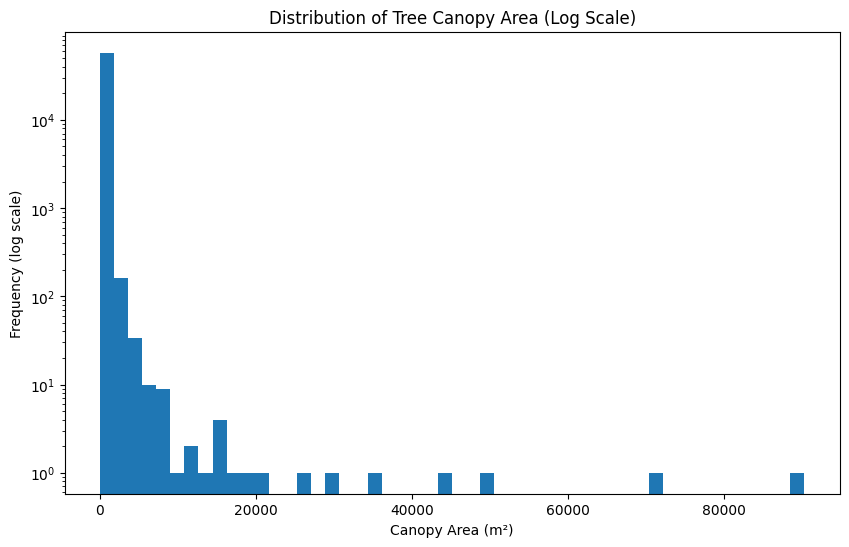

In [26]:
# Plot the distribution on a log scale.
plt.figure(figsize=(10, 6))
plt.hist(canopy_projected["canopy_area_m2"], bins=50, log=True)
plt.title("Distribution of Tree Canopy Area (Log Scale)")
plt.xlabel("Canopy Area (m²)")
plt.ylabel("Frequency (log scale)")
plt.show()

# 17. Creating an Analysis Grid

In [27]:
# Create a grid based on the thermal image bounds.
minx, miny, maxx, maxy = thermal_src.bounds

cell_size = 250  # in metres

grid_cells = []
x = minx
while x < maxx:
    y = miny
    while y < maxy:
        grid_cells.append(box(x, y, x + cell_size, y + cell_size))
        y += cell_size
    x += cell_size

grid_gdf = gpd.GeoDataFrame({"geometry": grid_cells}, crs=thermal_src.crs)

print("Grid created successfully.")
print("Number of grid cells:", len(grid_gdf))

Grid created successfully.
Number of grid cells: 1944


In [28]:
# Display the first 5 grid cells.
grid_gdf.head()

,geometry
0,"POLYGON ((313375.503 5808810.784, 313375.503 5..."
1,"POLYGON ((313375.503 5809060.784, 313375.503 5..."
2,"POLYGON ((313375.503 5809310.784, 313375.503 5..."
3,"POLYGON ((313375.503 5809560.784, 313375.503 5..."
4,"POLYGON ((313375.503 5809810.784, 313375.503 5..."


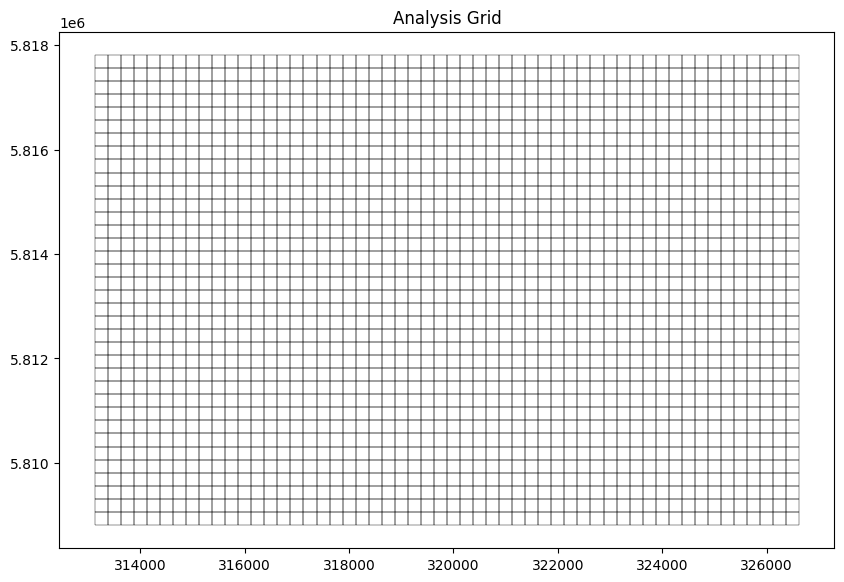

In [29]:
# Plot the analysis grid.
fig, ax = plt.subplots(figsize=(10, 10))
grid_gdf.boundary.plot(ax=ax, linewidth=0.3, color="black")
ax.set_title("Analysis Grid")
plt.show()

# 18. Calculating Grid Cell Area

In [30]:
# Calculate the area of each grid cell.
grid_gdf["grid_area_m2"] = grid_gdf.geometry.area

print(grid_gdf["grid_area_m2"].head())

0    62500.0
1    62500.0
2    62500.0
3    62500.0
4    62500.0
Name: grid_area_m2, dtype: float64


In [31]:
# Display summary statistics for grid cell area.
print(grid_gdf["grid_area_m2"].describe())

count     1944.0
mean     62500.0
std          0.0
min      62500.0
25%      62500.0
50%      62500.0
75%      62500.0
max      62500.0
Name: grid_area_m2, dtype: float64


# 19. Intersecting Tree Canopy with the Grid

In [32]:
# Intersect the reprojected canopy dataset with the analysis grid.
canopy_grid_intersection = gpd.overlay(canopy_projected, grid_gdf, how="intersection")

print("Intersection created successfully.")
print("Intersection shape:", canopy_grid_intersection.shape)    

Intersection created successfully.
Intersection shape: (61584, 4)


In [33]:
# Display the first 5 rows of the intersection result.
canopy_grid_intersection.head()

,geo_point_2d,canopy_area_m2,grid_area_m2,geometry
0,"{'lon': 144.93898465421296, 'lat': -37.7750630...",43.315200,62500.0,"POLYGON ((318486.818 5817145.442, 318486.818 5..."
1,"{'lon': 144.93979253397976, 'lat': -37.7751329...",4.435200,62500.0,"POLYGON ((318558.098 5817136.562, 318558.098 5..."
2,"{'lon': 144.94145114868167, 'lat': -37.7753604...",55.987200,62500.0,"POLYGON ((318705.939 5817117.362, 318705.939 5..."
3,"{'lon': 144.9397185484928, 'lat': -37.77547666...",0.691200,62500.0,"POLYGON ((318553.298 5817097.442, 318553.298 5..."
4,"{'lon': 144.9389680913816, 'lat': -37.77536268...",248.141256,62500.0,"POLYGON ((318488.978 5817121.922, 318488.978 5..."


# 20. Calculating Canopy Area within Each Grid Cell

In [34]:
# Calculate the area of each intersected canopy piece.
canopy_grid_intersection["intersection_area_m2"] = canopy_grid_intersection.geometry.area

print(canopy_grid_intersection["intersection_area_m2"].head())

0     43.315200
1      4.435200
2     55.987200
3      0.691200
4    248.141256
Name: intersection_area_m2, dtype: float64


In [35]:
# Display summary statistics for intersection area.
print(canopy_grid_intersection["intersection_area_m2"].describe())

count    61584.000000
mean        71.828890
std        400.162206
min          0.000623
25%          2.073600
50%         11.462448
75%         46.519906
max      27773.823698
Name: intersection_area_m2, dtype: float64


# 21. Summarising Canopy Area by Grid Cell

In [36]:
# Reset the grid index so each cell has a unique ID.
grid_gdf = grid_gdf.reset_index().rename(columns={"index": "grid_id"})
print(grid_gdf.head())

   grid_id                                           geometry  grid_area_m2
0        0  POLYGON ((313375.503 5808810.784, 313375.503 5...       62500.0
1        1  POLYGON ((313375.503 5809060.784, 313375.503 5...       62500.0
2        2  POLYGON ((313375.503 5809310.784, 313375.503 5...       62500.0
3        3  POLYGON ((313375.503 5809560.784, 313375.503 5...       62500.0
4        4  POLYGON ((313375.503 5809810.784, 313375.503 5...       62500.0


In [37]:
# Re-run the intersection using the grid with grid_id.
canopy_grid_intersection = gpd.overlay(canopy_projected, grid_gdf, how="intersection")

# Calculate the intersected canopy area again.
canopy_grid_intersection["intersection_area_m2"] = canopy_grid_intersection.geometry.area

print("Intersection recreated successfully.")
print(canopy_grid_intersection.head())

Intersection recreated successfully.
                                        geo_point_2d  canopy_area_m2  grid_id  \
0  {'lon': 144.93898465421296, 'lat': -37.7750630...       43.315200      789   
1  {'lon': 144.93979253397976, 'lat': -37.7751329...        4.435200      789   
2  {'lon': 144.94145114868167, 'lat': -37.7753604...       55.987200      825   
3  {'lon': 144.9397185484928, 'lat': -37.77547666...        0.691200      789   
4  {'lon': 144.9389680913816, 'lat': -37.77536268...      248.141256      789   

   grid_area_m2                                           geometry  \
0       62500.0  POLYGON ((318486.818 5817145.442, 318486.818 5...   
1       62500.0  POLYGON ((318558.098 5817136.562, 318558.098 5...   
2       62500.0  POLYGON ((318705.939 5817117.362, 318705.939 5...   
3       62500.0  POLYGON ((318553.298 5817097.442, 318553.298 5...   
4       62500.0  POLYGON ((318488.978 5817121.922, 318488.978 5...   

   intersection_area_m2  
0             43.315200  
1  

In [38]:
# Sum canopy area within each grid cell.
canopy_by_grid = canopy_grid_intersection.groupby("grid_id")["intersection_area_m2"].sum().reset_index()

print(canopy_by_grid.head())

   grid_id  intersection_area_m2
0      256            101.491656
1      257             88.474344
2      258             15.335252
3      259             12.479530
4      290              0.988994


# 22. Calculating Canopy Cover Percentage

In [39]:
# Merge the canopy totals back into the grid.
grid_gdf = grid_gdf.merge(canopy_by_grid, on="grid_id", how="left")

# Fill missing canopy values with 0.
grid_gdf["intersection_area_m2"] = grid_gdf["intersection_area_m2"].fillna(0)

# Calculate canopy cover percentage.
grid_gdf["canopy_cover_pct"] = (grid_gdf["intersection_area_m2"] / grid_gdf["grid_area_m2"]) * 100

print(grid_gdf[["grid_id", "grid_area_m2", "intersection_area_m2", "canopy_cover_pct"]].head())

   grid_id  grid_area_m2  intersection_area_m2  canopy_cover_pct
0        0       62500.0                   0.0               0.0
1        1       62500.0                   0.0               0.0
2        2       62500.0                   0.0               0.0
3        3       62500.0                   0.0               0.0
4        4       62500.0                   0.0               0.0


In [40]:
# Summary statistics for canopy cover percentage.
print(grid_gdf["canopy_cover_pct"].describe())

count    1944.000000
mean        3.640749
std         7.838087
min         0.000000
25%         0.000000
50%         0.000000
75%         3.080734
max        52.760906
Name: canopy_cover_pct, dtype: float64


# 23. Calculating Thermal Intensity for Each Grid Cell

In [41]:
# Calculate the mean thermal value for each grid cell.
thermal_means = []

for geom in grid_gdf.geometry:
    try:
        out_image, out_transform = mask(thermal_src, [geom], crop=True)
        data = out_image.astype(float)

        # Convert 0 values to NaN only if you want to ignore possible background pixels.
        data[data == 0] = np.nan

        thermal_means.append(np.nanmean(data))
    except:
        thermal_means.append(np.nan)

grid_gdf["mean_thermal"] = thermal_means

print(grid_gdf["mean_thermal"].head())

0    255.0
1    255.0
2    255.0
3    255.0
4    255.0
Name: mean_thermal, dtype: float64


In [42]:
# Summary statistics for mean thermal values.
print(grid_gdf["mean_thermal"].describe())

count    1944.000000
mean      227.019787
std        40.153707
min       137.663882
25%       176.268002
50%       255.000000
75%       255.000000
max       255.000000
Name: mean_thermal, dtype: float64


# 24. Exploring Thermal Intensity Distribution

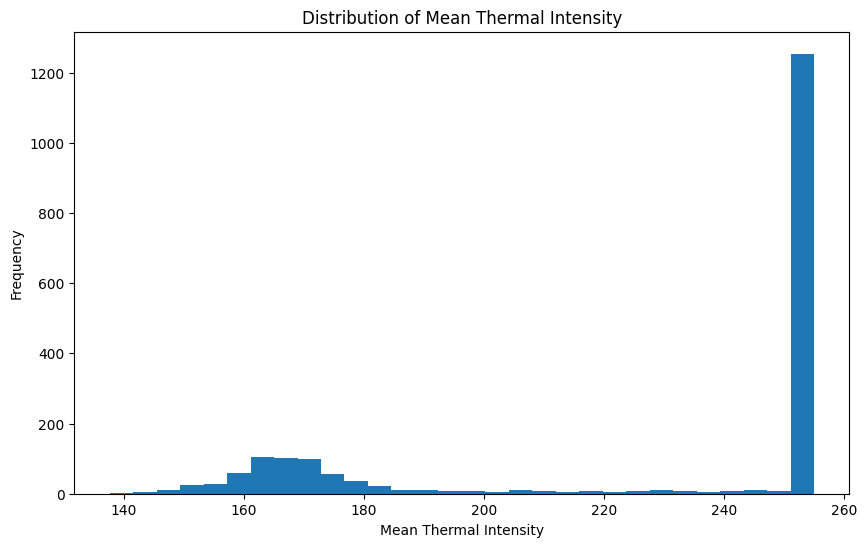

In [43]:
# Plot the distribution of mean thermal intensity.
plt.figure(figsize=(10, 6))
plt.hist(grid_gdf["mean_thermal"], bins=30)
plt.title("Distribution of Mean Thermal Intensity")
plt.xlabel("Mean Thermal Intensity")
plt.ylabel("Frequency")
plt.show()

In [44]:
# Display the first 10 rows of thermal and canopy indicators together.
print(grid_gdf[["grid_id", "canopy_cover_pct", "mean_thermal"]].head(10))

   grid_id  canopy_cover_pct  mean_thermal
0        0               0.0         255.0
1        1               0.0         255.0
2        2               0.0         255.0
3        3               0.0         255.0
4        4               0.0         255.0
5        5               0.0         255.0
6        6               0.0         255.0
7        7               0.0         255.0
8        8               0.0         255.0
9        9               0.0         255.0


# 25. Identifying High Thermal and Low Canopy Cells

In [45]:
# Define thresholds.
thermal_threshold = grid_gdf["mean_thermal"].quantile(0.75)
canopy_threshold = 5.0

print("Thermal threshold:", thermal_threshold)
print("Canopy threshold:", canopy_threshold)

Thermal threshold: 255.0
Canopy threshold: 5.0


In [46]:
# Create classification columns.
grid_gdf["high_thermal"] = grid_gdf["mean_thermal"] >= thermal_threshold
grid_gdf["low_canopy"] = grid_gdf["canopy_cover_pct"] < canopy_threshold

# Final priority cells.
grid_gdf["priority_cell"] = grid_gdf["high_thermal"] & grid_gdf["low_canopy"]

print(grid_gdf[["high_thermal", "low_canopy", "priority_cell"]].sum())

high_thermal     1235
low_canopy       1527
priority_cell    1235
dtype: int64


# 26. Visualising Priority Cells

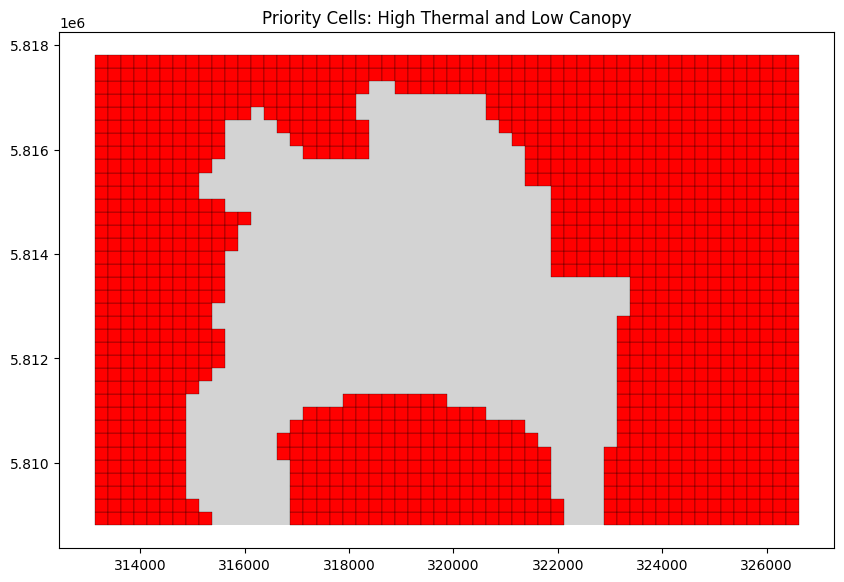

In [47]:
# Plot priority cells.
fig, ax = plt.subplots(figsize=(10, 10))

grid_gdf.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="none"
)

grid_gdf[grid_gdf["priority_cell"]].plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=0.2
)

ax.set_title("Priority Cells: High Thermal and Low Canopy")
plt.show()

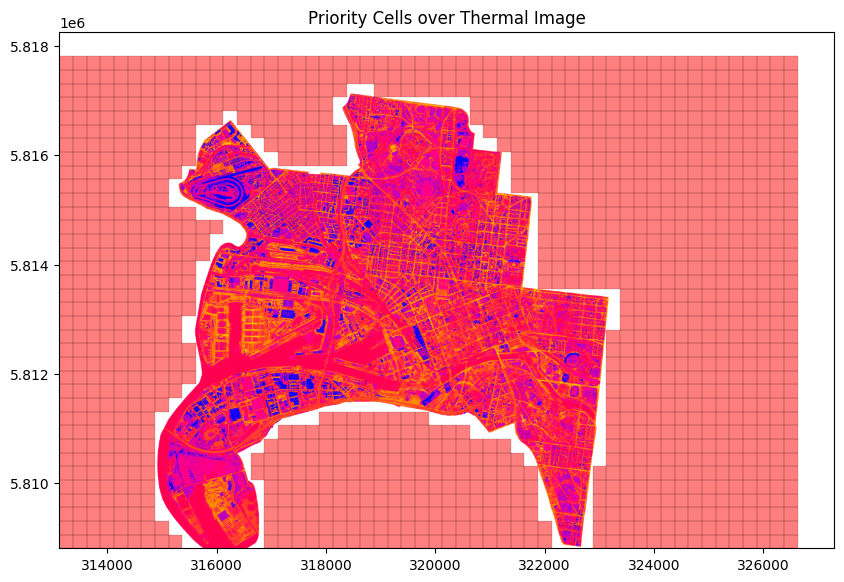

In [48]:
# Overlay priority cells on the thermal image.
fig, ax = plt.subplots(figsize=(10, 10))

show(thermal_src, ax=ax)

grid_gdf[grid_gdf["priority_cell"]].plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=0.2,
    alpha=0.5
)

ax.set_title("Priority Cells over Thermal Image")
plt.show()